<a href="https://colab.research.google.com/github/saranya3197/Predictive-Analytics/blob/Predict-likelihood-of-mental-health-issues-based-on-stress-levels/Predict_likelihood_of_mental_health_issues_based_on_stress_levels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.88      0.82      0.85        17

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31


Confusion Matrix:
 [[12  2]
 [ 3 14]]


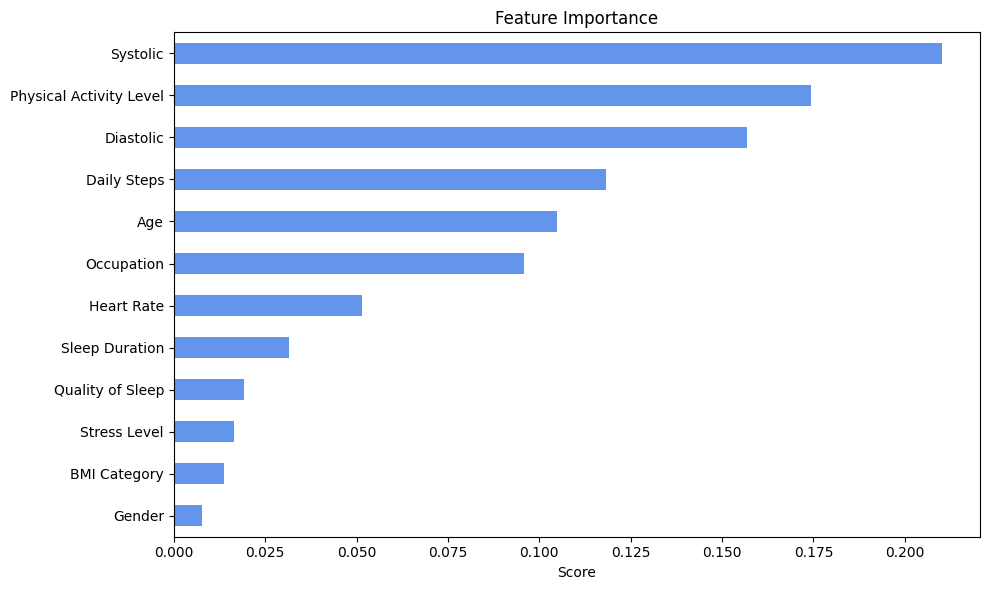

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Step 1: Load Dataset
df = pd.read_csv("Sleep_health.csv")

# Step 2: Drop unnecessary column
if 'Person ID' in df.columns:
    df.drop('Person ID', axis=1, inplace=True)

# Step 3: Drop rows with missing values
df.dropna(inplace=True)

# Step 4: Split 'Blood Pressure' into 'Systolic' and 'Diastolic'
if 'Blood Pressure' in df.columns:
    bp_split = df['Blood Pressure'].str.split('/', expand=True)
    df['Systolic'] = pd.to_numeric(bp_split[0], errors='coerce')
    df['Diastolic'] = pd.to_numeric(bp_split[1], errors='coerce')
    df.drop('Blood Pressure', axis=1, inplace=True)

# Drop rows with NaN after blood pressure conversion
df.dropna(inplace=True)

# Step 5: Encode categorical features
label_encoders = {}
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Step 6: Prepare features and target
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# Step 7: Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Step 9: Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 10: Predict and Evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 11: Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='cornflowerblue')
plt.title("Feature Importance")
plt.xlabel("Score")
plt.tight_layout()
plt.show()